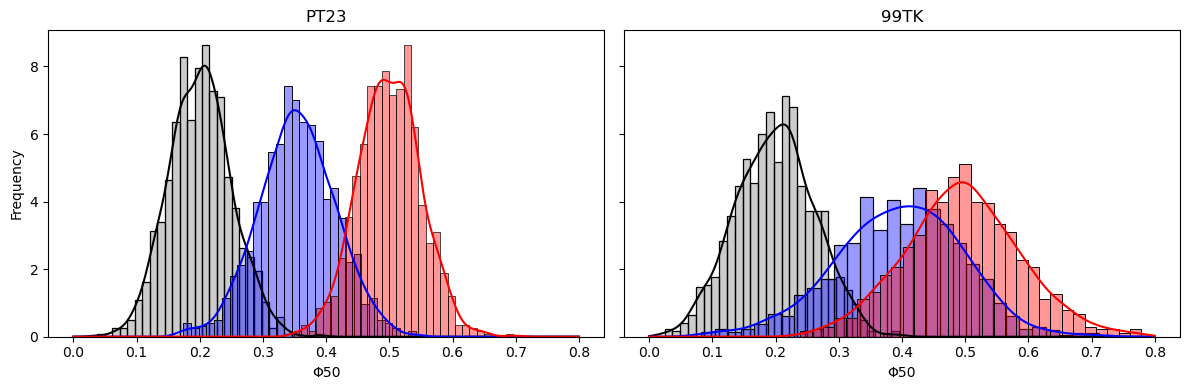

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

np.random.seed(42)

# ---------- PARAMETERS ----------
n = 1000

# PT23 (clear rightward shift)
pt23_anc_mean, pt23_anc_sd = 0.2, 0.05
pt23_t2_mean, pt23_t2_sd   = 0.35, 0.06
pt23_t3_mean, pt23_t3_sd   = 0.50, 0.05

# 99TK (broader, overlapping shift)
tk99_anc_mean, tk99_anc_sd = 0.2, 0.06
tk99_t2_mean, tk99_t2_sd   = 0.40, 0.10
tk99_t3_mean, tk99_t3_sd   = 0.50, 0.09

# ---------- GENERATE DATA ----------
pt23_anc = np.random.normal(pt23_anc_mean, pt23_anc_sd, n)
pt23_t2  = np.random.normal(pt23_t2_mean,  pt23_t2_sd,  n)
pt23_t3  = np.random.normal(pt23_t3_mean,  pt23_t3_sd,  n)

tk99_anc = np.random.normal(tk99_anc_mean, tk99_anc_sd, n)
tk99_t2  = np.random.normal(tk99_t2_mean,  tk99_t2_sd,  n)
tk99_t3  = np.random.normal(tk99_t3_mean,  tk99_t3_sd,  n)

# ---------- PLOTTING FUNCTION ----------
def plot_panel(ax, anc, t2, t3, title):
    bins = 30

    sns.histplot(anc, bins=bins, stat="density",
                 color="gray", alpha=0.4, ax=ax)
    sns.histplot(t2, bins=bins, stat="density",
                 color="blue", alpha=0.4, ax=ax)
    sns.histplot(t3, bins=bins, stat="density",
                 color="red", alpha=0.4, ax=ax)

    # KDE lines
    x_vals = np.linspace(0, 0.8, 500)
    ax.plot(x_vals, gaussian_kde(anc)(x_vals), color="black")
    ax.plot(x_vals, gaussian_kde(t2)(x_vals), color="blue")
    ax.plot(x_vals, gaussian_kde(t3)(x_vals), color="red")

    # Φ50 marker (example at 0.45)
    ax.set_xlabel("Φ50")
    ax.set_ylabel("Frequency")
    ax.set_title(title)

# ---------- FIGURE ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

plot_panel(axes[0], pt23_anc, pt23_t2, pt23_t3, "PT23")
plot_panel(axes[1], tk99_anc, tk99_t2, tk99_t3, "99TK")

plt.tight_layout()
plt.show()
